In [ ]:
# Phân tích dữ liệu bán hàng với bộ dữ liệu Superstore
# Notebook này thực hiện:
# - Đọc và khám phá dữ liệu
# - Phân tích khám phá dữ liệu
# - Trực quan hóa dữ liệu
# - Rút ra insight phục vụ 

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [ ]:
df = pd.read_csv("../Data/Superstore Sale Dataset.csv", encoding="latin1")

df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%m/%d/%Y")

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month_name()
df["Month Number"] = df["Order Date"].dt.month
df["YearMonth"] = df["Order Date"].dt.to_period("M").astype(str)

print("Đọc dữ liệu thành công.")

Đọc dữ liệu thành công.


In [14]:
## 4.1 Đọc và khám phá dữ liệu
print("Kích thước dữ liệu", df.shape)

Kích thước dữ liệu (9994, 25)


In [15]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month Number,YearMonth
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,November,11,2016-11
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,November,11,2016-11
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,June,6,2016-06
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,October,10,2015-10
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,October,10,2015-10


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [17]:
print("Thống kê mô tả:")
df.describe()

Thống kê mô tả:


,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,Year,Month Number
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896,2015.722233,7.809686
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,2014.000000,1.000000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750,2015.000000,5.000000
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500,2016.000000,9.000000
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000,2017.000000,11.000000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000,2017.000000,12.000000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108,1.123555,3.284654


In [18]:
tong_thieu = df.isnull().sum().sum()
df.isnull().sum()
print(f"Số giá trị thiếu là: {tong_thieu}")

Số giá trị thiếu là: 0


In [19]:
#Kiểm tra giá trị trùng lặp
df.duplicated().sum()

np.int64(0)

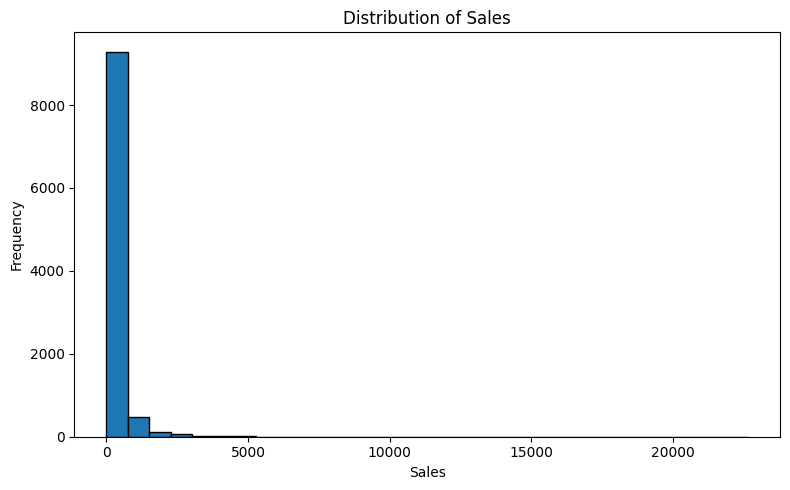

In [ ]:
#Biểu đồ phân bố Doanh thu
plt.figure(figsize=(8, 5))
plt.hist(df["Sales"], bins=30, edgecolor="black")
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

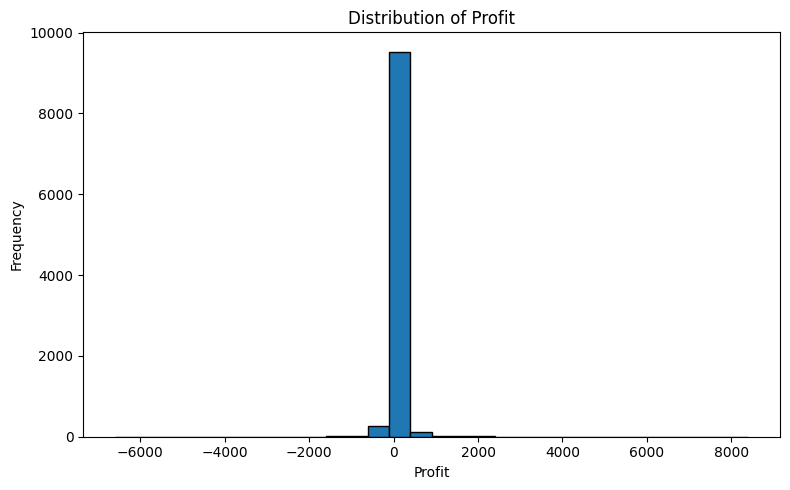

In [15]:
#Biểu đô phân bố Profit
plt.figure(figsize=(8, 5))
plt.hist(df['Profit'], bins=30, edgecolor="black")
plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

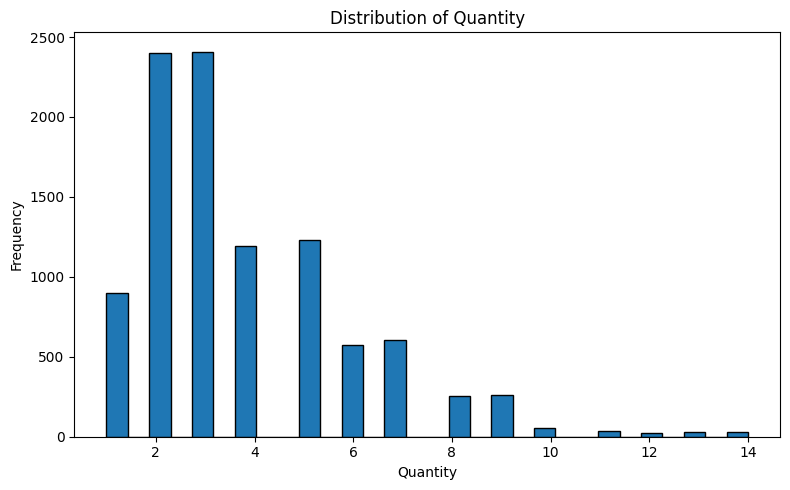

In [16]:
plt.figure(figsize=(8, 5))
plt.hist(df["Quantity"], bins=30, edgecolor="black")
plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
## Phân tích khám phá dữ liệu (EDA)
#Doanh thu theo thời gian
monthly_sales = df.groupby("YearMonth")["Sales"].sum().reset_index()
monthly_sales.head()

,YearMonth,Sales
0,2014-01,14236.895
1,2014-02,4519.892
2,2014-03,55691.009
3,2014-04,28295.345
4,2014-05,23648.287


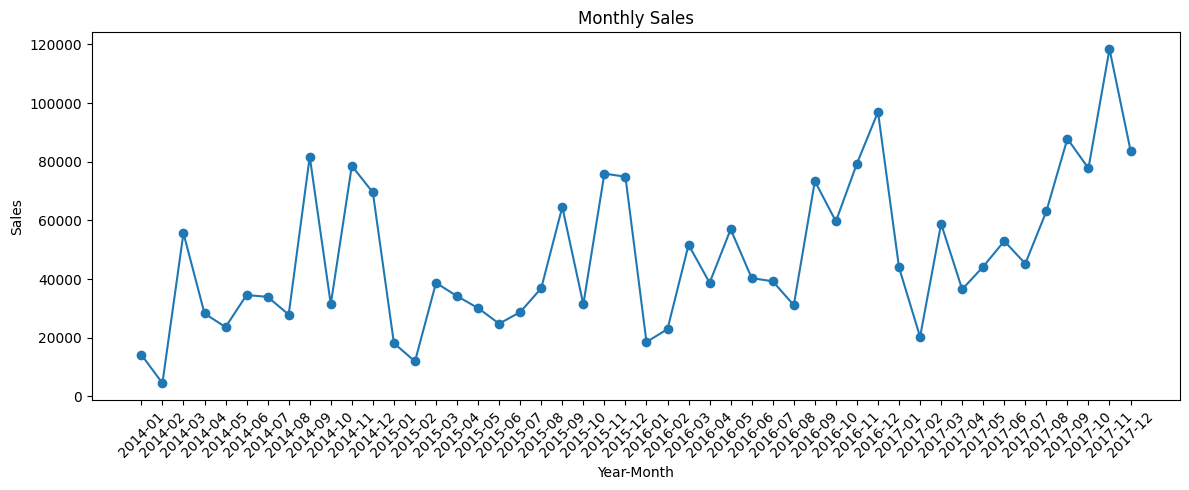

In [18]:
#Biểu đồ doanh thu theo tháng
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales["YearMonth"], monthly_sales["Sales"], marker="o")
plt.title("Monthly Sales")
plt.xlabel("Year-Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
#Lợi nhuận theo thời gian
monthly_profit = df.groupby("YearMonth")["Profit"].sum().reset_index()
monthly_profit.head()

,YearMonth,Profit
0,2014-01,2450.1907
1,2014-02,862.3084
2,2014-03,498.7299
3,2014-04,3488.8352
4,2014-05,2738.7096


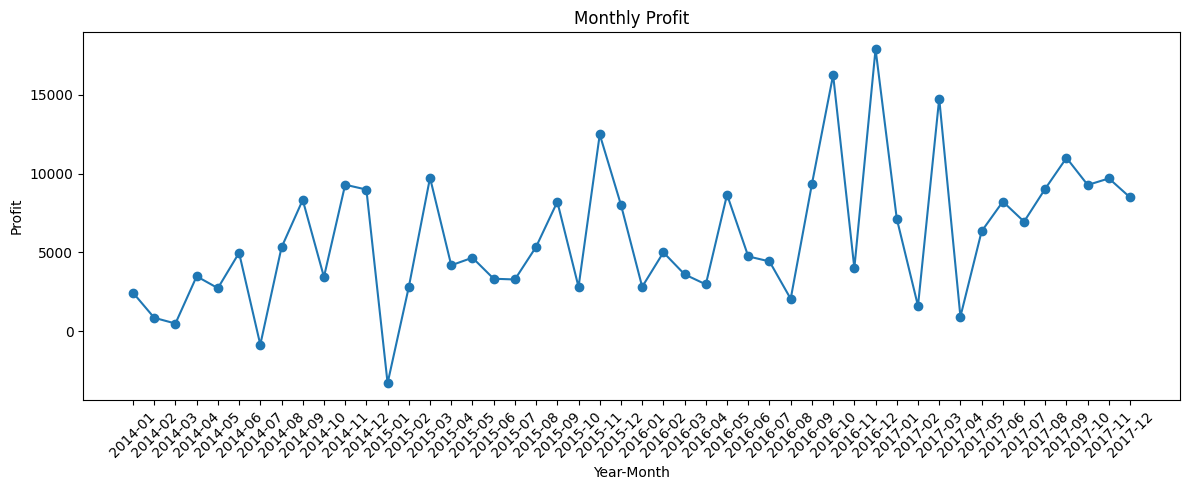

In [20]:
#Biểu đồ lợi nhuận theo tháng
plt.figure(figsize=(12, 5))
plt.plot(monthly_profit["YearMonth"], monthly_profit["Profit"], marker="o")
plt.title("Monthly Profit")
plt.xlabel("Year-Month")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
#Doanh thu theo khu vực
sales_by_region = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
sales_by_region

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

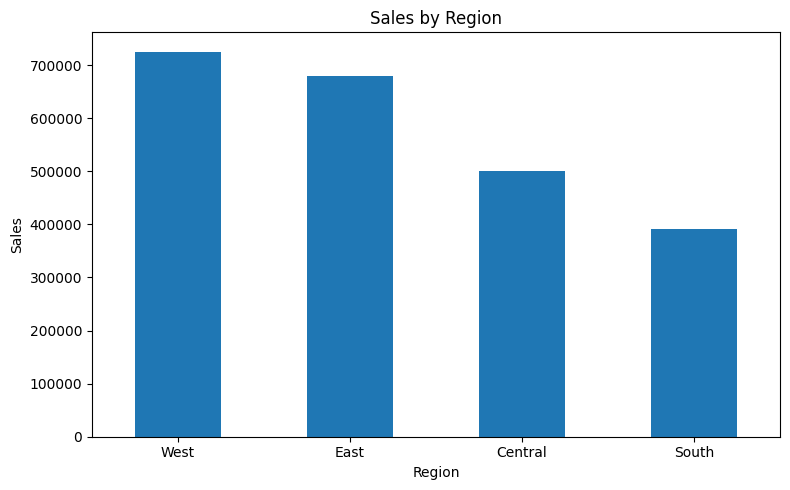

In [22]:
#Biểu đồ doanh thu theo khu vực
plt.figure(figsize=(8, 5))
sales_by_region.plot(kind="bar")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
#Doanh thu và lợi nhuận theo Các nhóm sản phẩm
category_summary = df.groupby("Category")[["Sales", "Profit"]].sum().sort_values(by="Sales", ascending=False)
category_summary

,Sales,Profit
Category,,
Technology,836154.0330,145454.9481
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008


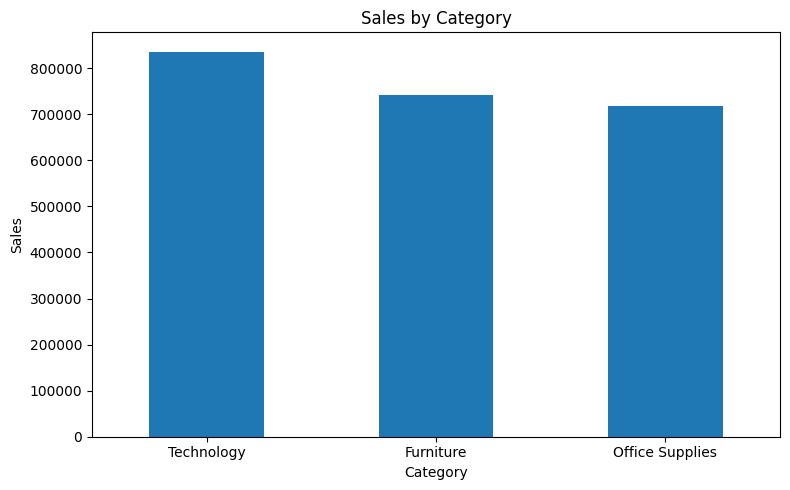

In [ ]:
#Biểu đồ doanh thu theo Các nhóm sản phẩm
plt.figure(figsize=(8, 5))
category_summary["Sales"].plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.tight_layout()  
plt.show()

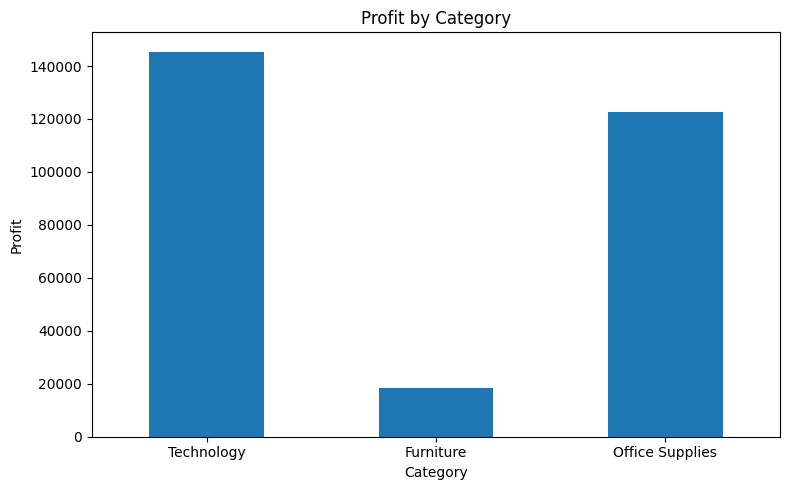

In [25]:
#Biểu đồ lợi nhuận theo category
plt.figure(figsize=(8, 5))
category_summary["Profit"].plot(kind="bar")
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.xticks(rotation=0)
plt.tight_layout()  
plt.show()

In [26]:
#Doanh thu theo Sub-Category
subcat_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)
subcat_sales

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: Sales, dtype: float64

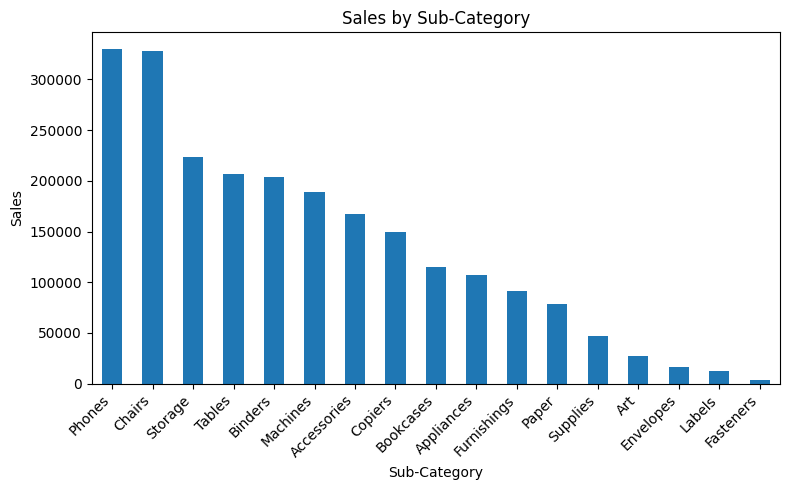

In [27]:
#Biểu đồ doanh thu theo Sub-Category
plt.figure(figsize=(8, 5))
subcat_sales.plot(kind="bar")
plt.title("Sales by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Sales")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()  
plt.show()

In [28]:
#Lợi nhuận theo Sub-Category
subcat_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False)
subcat_profit

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Art             6527.7870
Labels          5546.2540
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64

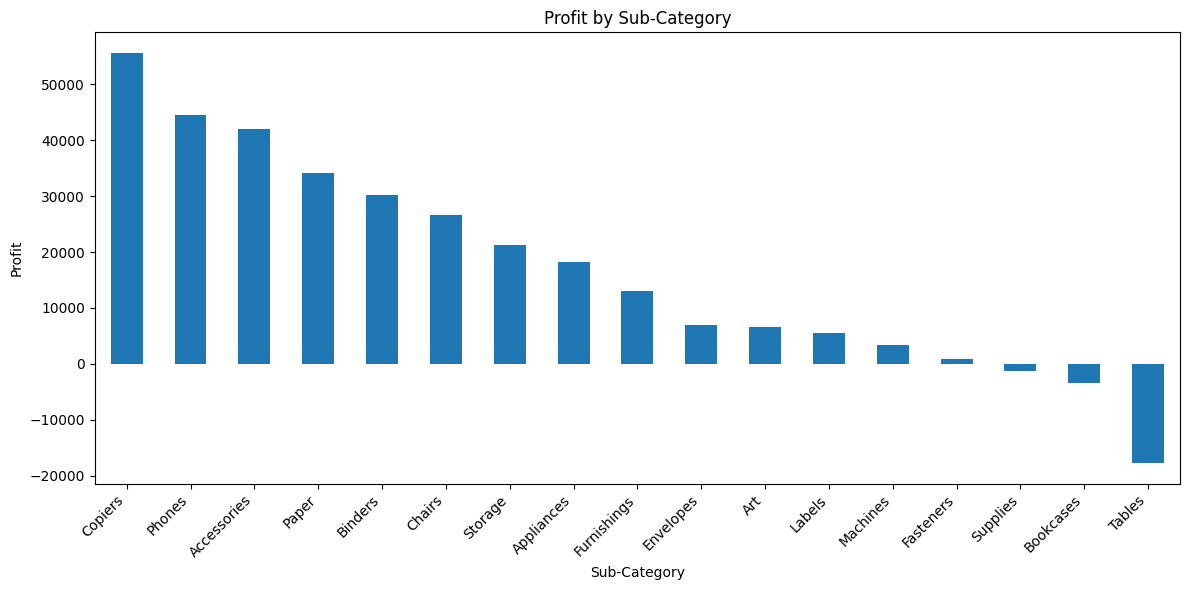

In [29]:
#Biểu đồ lợi nhuận theo Sub-Category
plt.figure(figsize=(12, 6))
subcat_profit.plot(kind="bar")
plt.title("Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Profit")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()  
plt.show()

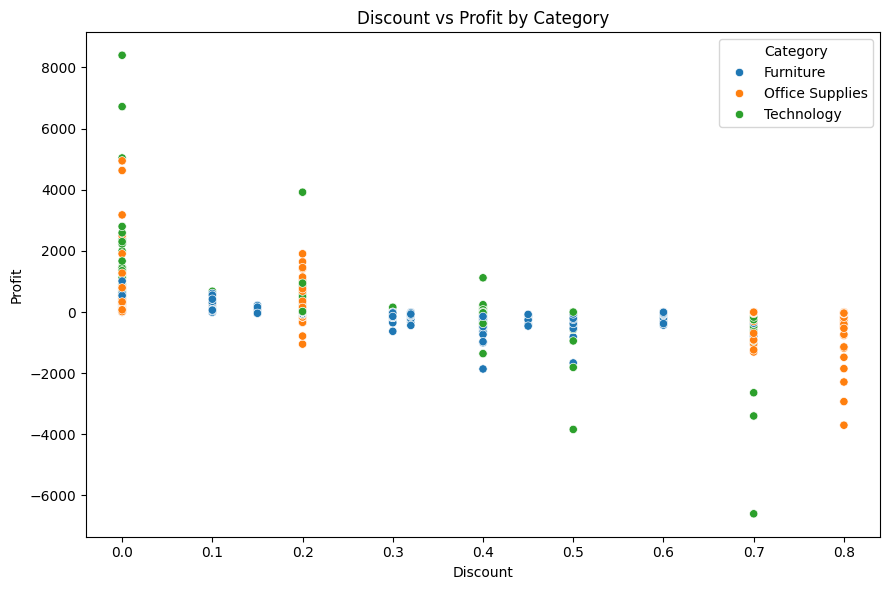

In [30]:
#Biểu đồ giữa Lợi nhuận và Giảm giá
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="Discount", y="Profit", hue="Category")
plt.title("Discount vs Profit by Category")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

In [31]:
corr_cols = ["Sales", "Profit", "Discount", "Quantity"]
corr_matrix = df[corr_cols].corr()
corr_matrix

,Sales,Profit,Discount,Quantity
Sales,1.000000,0.479064,-0.028190,0.200795
Profit,0.479064,1.000000,-0.219487,0.066253
Discount,-0.028190,-0.219487,1.000000,0.008623
Quantity,0.200795,0.066253,0.008623,1.000000


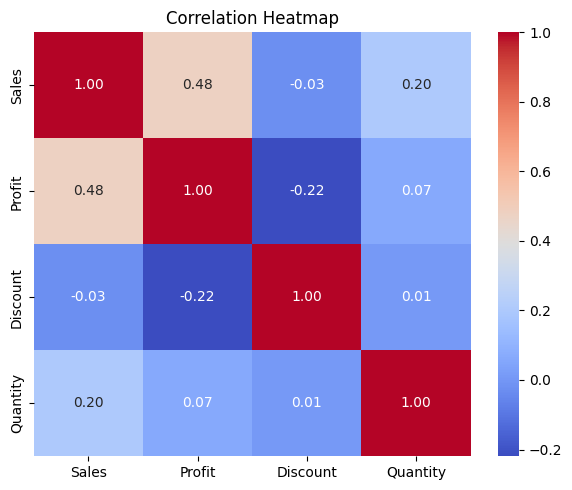

In [ ]:
## Trực quan hóa dữ liệu
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
#Top 10 sản phẩm có doanh thu cao nhất
top_products_sales = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
top_products_sales

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

C:\Users\Admin\AppData\Local\Temp\ipykernel_17448\424680392.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


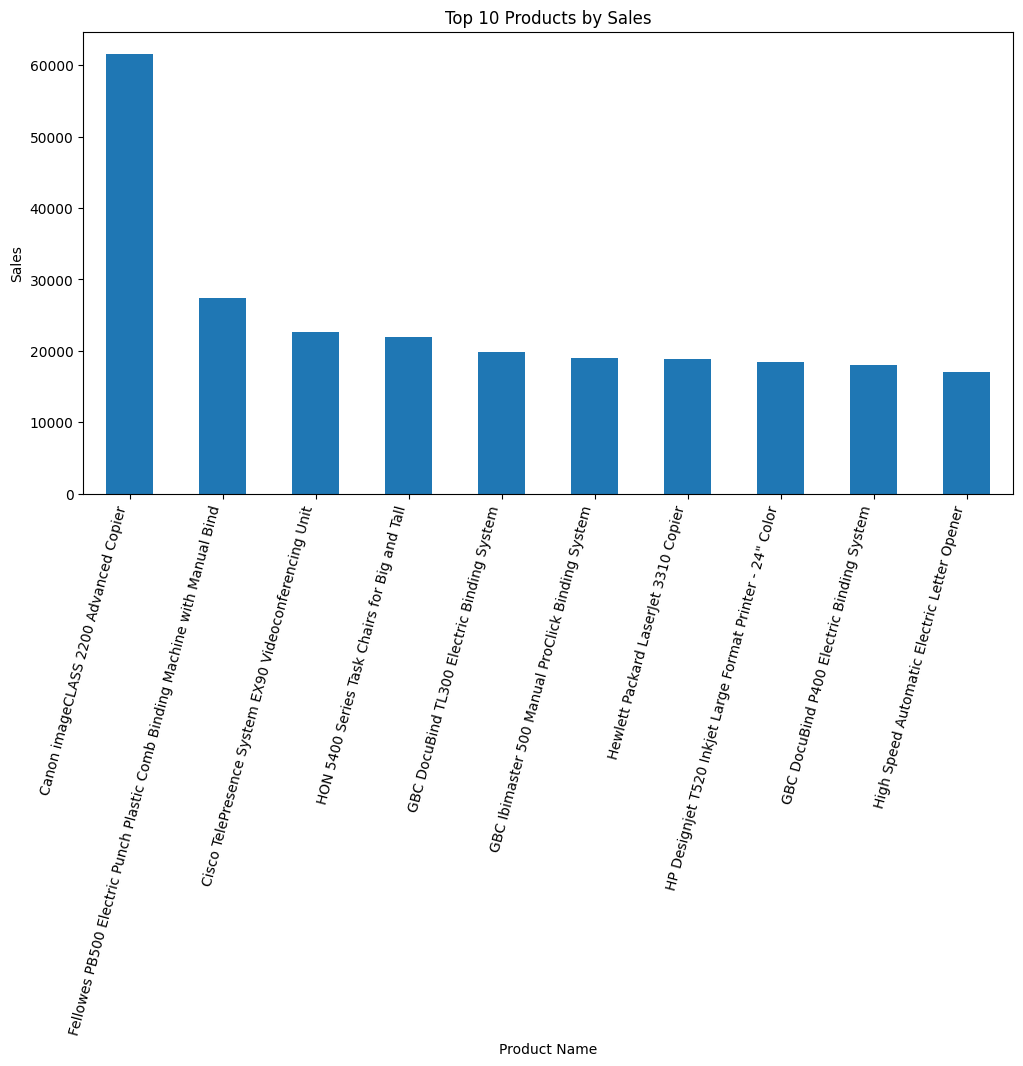

In [34]:
#Biểu đồ Top 10 sản phẩm có doanh thu cao nhất
plt.figure(figsize=(12, 6))
top_products_sales.plot(kind="bar")
plt.title("Top 10 Products by Sales")
plt.xlabel("Product Name")
plt.ylabel("Sales")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

In [35]:
#Top 10 sản phẩm có lợi nhuận thấp nhất
bottom_products_profit = df.groupby("Product Name")["Profit"].sum().sort_values().head(10)
bottom_products_profit

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64

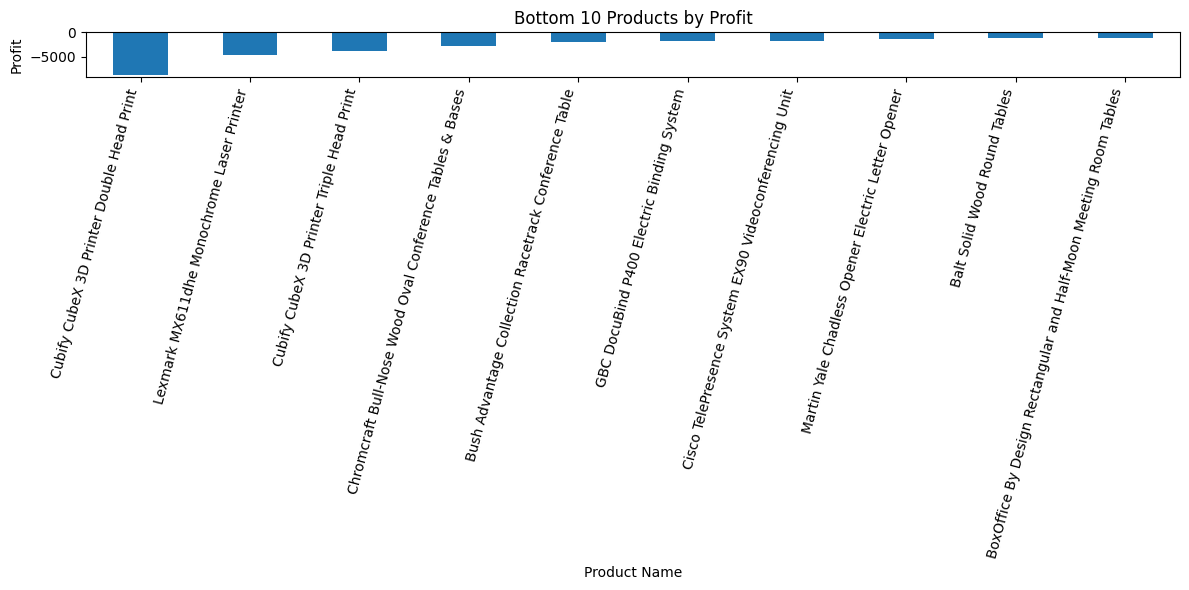

In [36]:
#Biểu đồ Top 10 sản phẩm có lợi nhuận thấp nhất
plt.figure(figsize=(12, 6))
bottom_products_profit.plot(kind="bar")
plt.title("Bottom 10 Products by Profit")
plt.xlabel("Product Name")
plt.ylabel("Profit")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

In [37]:
## 4.4 Rút ra insight
top_region = sales_by_region.idxmax()
top_region_value = sales_by_region.max()

print(f"Khu vực có doanh thu cao nhất: {top_region} ({top_region_value:.2f})")

best_subcat = subcat_profit.idxmax()
best_subcat_value = subcat_profit.max()

print(f"Nhóm sản phẩm có lợi nhuận cao nhất: {best_subcat} ({best_subcat_value:.2f})")
print(f"")

loss_subcat = subcat_profit[subcat_profit < 0]
print(f"Nhóm sản phẩm bị lỗ:", loss_subcat)
print(f"")

discount_profit_corr = df["Discount"].corr(df["Profit"])
print(f"Hệ số tương quan giữa Discount và Profit: {discount_profit_corr:.4f}")

if discount_profit_corr < 0:
    print("Nhận xét: Discount có xu hướng tăng thì Profit giảm.")
else:
    print("Nhận xét: Chưa thấy mối quan hệ âm rõ ràng giữa Discount và Profit.")

Khu vực có doanh thu cao nhất: West (725457.82)
Nhóm sản phẩm có lợi nhuận cao nhất: Copiers (55617.82)

Nhóm sản phẩm bị lỗ: Sub-Category
Supplies     -1189.0995
Bookcases    -3472.5560
Tables      -17725.4811
Name: Profit, dtype: float64

Hệ số tương quan giữa Discount và Profit: -0.2195
Nhận xét: Discount có xu hướng tăng thì Profit giảm.


In [38]:
print("TỔNG HỢP INSIGHT:")
print(f"1. Khu vực có doanh thu cao nhất: {top_region}")
print(f"2. Nhóm sản phẩm có lợi nhuận tốt nhất: {best_subcat}")
print("3. Một số nhóm sản phẩm có lợi nhuận âm, cần được xem xét kỹ hơn.")
print("4. Discount có thể ảnh hưởng tiêu cực đến Profit(Discount có xu hướng tăng thì Profit giảm).")
print("5. Kết quả EDA hỗ trợ và củng cố các quan sát từ dashboard Power BI.")

TỔNG HỢP INSIGHT:
1. Khu vực có doanh thu cao nhất: West
2. Nhóm sản phẩm có lợi nhuận tốt nhất: Copiers
3. Một số nhóm sản phẩm có lợi nhuận âm, cần được xem xét kỹ hơn.
4. Discount có thể ảnh hưởng tiêu cực đến Profit(Discount có xu hướng tăng thì Profit giảm).
5. Kết quả EDA hỗ trợ và củng cố các quan sát từ dashboard Power BI.
